# 结课项目：实时数字 CTC 声学引擎

这一次不再分别学习“Log-Mel、声学编码器、CTC、streaming、RTF”。我们要沿一条真实数据流检查每个接口：

`WAV → PCM → Stateful Log-Mel → Causal encoder → CTC logits → Prefix/Greedy decoder → partial/final → CER/RTF/PGS`

本项目使用仓库里的 FSDD 开源真人数字录音和真正训练得到的 PyTorch checkpoint。它能证明端到端代码、状态和指标链路成立，但只有极小训练集，**不能代表通用 ASR 能力**。

最重要的学习目标不是让演示“看起来都识别对”，而是学会同时回答：

- 系统有没有按契约运行？
- 训练内、同分布、说话人独立测试分别表现怎样？
- chunk 改变时数值和最终文本是否一致？
- 什么时候能说快、稳、准，什么时候必须明确说证据不足？

## 完成标准

- 能从代码和 shape 解释 `[samples] → [T,F] → [B,T,C] → text`；
- 能口述流式前端 buffer、声学模型 cache、CTC decoder state 三类状态；
- 能证明整段与随机 chunk 的特征/logits 在容差内一致；
- 能计算 CER、RTF、partial revision 和 final-prefix agreement；
- 能解释为什么训练风格高分与跨说话人低分并不矛盾；
- 能把 checkpoint、特征配置、词表和归一化统计当作一个版本化契约；
- 末尾 64 分答辩至少达到 52 分。

建议分 4 次、每次 75～100 分钟完成。

In [1]:
from pathlib import Path
import hashlib
import math
import subprocess
import sys
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager
import soundfile as sf
import librosa.display
import ipywidgets as widgets
from IPython.display import Audio, display

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "Noto Sans CJK SC", "SimHei", "Arial Unicode MS"]:
    if font_name in installed_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(p for p in candidates if (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from acoustic_engine.features import LogMelFrontend, StreamingLogMelFrontend, load_mono_audio
from acoustic_engine.streaming import StreamingAcousticEngine
from acoustic_engine.decoder import ctc_collapse, prefix_beam_search
from acoustic_engine.language_model import AddKBigramLanguageModel, ShallowFusionScorer
from acoustic_engine.train_digits import load_digit_parts, join_digits

CHECKPOINT = ROOT / "artifacts" / "streaming_digit_ctc.pt"
engine = StreamingAcousticEngine.load(CHECKPOINT)
parts, sample_rate = load_digit_parts(ROOT / "data" / "spoken_digits_parts")
print("项目根目录:", ROOT)
print("checkpoint:", CHECKPOINT, CHECKPOINT.stat().st_size, "bytes")
print("device: CPU; torch:", torch.__version__)

项目根目录: <REPO_ROOT>
checkpoint: <REPO_ROOT>\artifacts\streaming_digit_ctc.pt 203011 bytes
device: CPU; torch: 2.13.0+cpu


## 1. 先看完整契约，不急着看模型层

一个可加载的 checkpoint 不只是权重。至少要绑定：

- 采样率、FFT/window/hop、Mel 维数、是否 peak normalize；
- feature mean/std；
- 模型结构参数和权重；
- token 顺序、blank ID 与 checkpoint format version。

任何一项错位都可能“代码能跑但结果全错”。流式版本禁止 utterance-level peak normalization，因为系统收到开头时还不知道整句未来最大幅值。

In [2]:
config = engine.frontend_config
parameter_count = sum(p.numel() for p in engine.model.parameters())
checkpoint_sha256 = hashlib.sha256(CHECKPOINT.read_bytes()).hexdigest()
contract = {
    "sample_rate": config.sample_rate,
    "n_fft": config.n_fft,
    "win_length": config.win_length,
    "hop_length": config.hop_length,
    "n_mels": config.n_mels,
    "peak_normalize": config.peak_normalize,
    "model": type(engine.model).__name__,
    "parameters": parameter_count,
    "classes": len(engine.tokens) + 1,
    "tokens": "".join(engine.tokens),
    "feature_mean_shape": tuple(engine.feature_mean.shape),
    "feature_std_shape": tuple(engine.feature_std.shape),
    "sha256_prefix": checkpoint_sha256[:16],
}
for key, value in contract.items():
    print(f"{key:22s}: {value}")
assert config.sample_rate == 8000
assert not config.peak_normalize
assert len(engine.tokens) + 1 == engine.model.config.num_classes
assert engine.feature_mean.shape == (config.n_mels,)

sample_rate           : 8000
n_fft                 : 256
win_length            : 200
hop_length            : 160
n_mels                : 24
peak_normalize        : False
model                 : CausalConvCTCAcousticModel
parameters            : 48491
classes               : 11
tokens                : 0123456789
feature_mean_shape    : (24,)
feature_std_shape     : (24,)
sha256_prefix         : 90fbd1ccd6ece2e7


### 契约检查题（每题 2 分）

1. 为什么只保存 `state_dict` 仍不足以可靠部署？
2. token 顺序从 `012...9` 变成 `102...9`，shape 没变，结果会怎样？
3. 训练使用 peak normalization、流式推理不用，会造成哪类分布偏移？
4. SHA256 不能说明模型质量，却为什么仍值得记录？

<details><summary>参考答案</summary>

还缺结构、前端、词表、统计量和版本；类别 ID 会被映射成错误字符；输入尺度/特征统计不一致；哈希能唯一核对部署的二进制是否与已验收版本相同。

</details>

## 2. 一条真实 WAV 穿过所有 shape

我们先使用真人说出的数字 7。请在运行前预测：

- 8 kHz、约 0.43 秒大约有多少 samples？
- `hop=160` 意味着每秒大约多少特征帧？
- 11 个输出类别分别是什么？

waveform [samples]        = (3457,)
Log-Mel [time, mel]      = (21, 24)
batch [batch,time,mel]   = (1, 21, 24)
logits [batch,time,class]= (1, 21, 11)
frame ids → CTC collapse = [8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] → 7


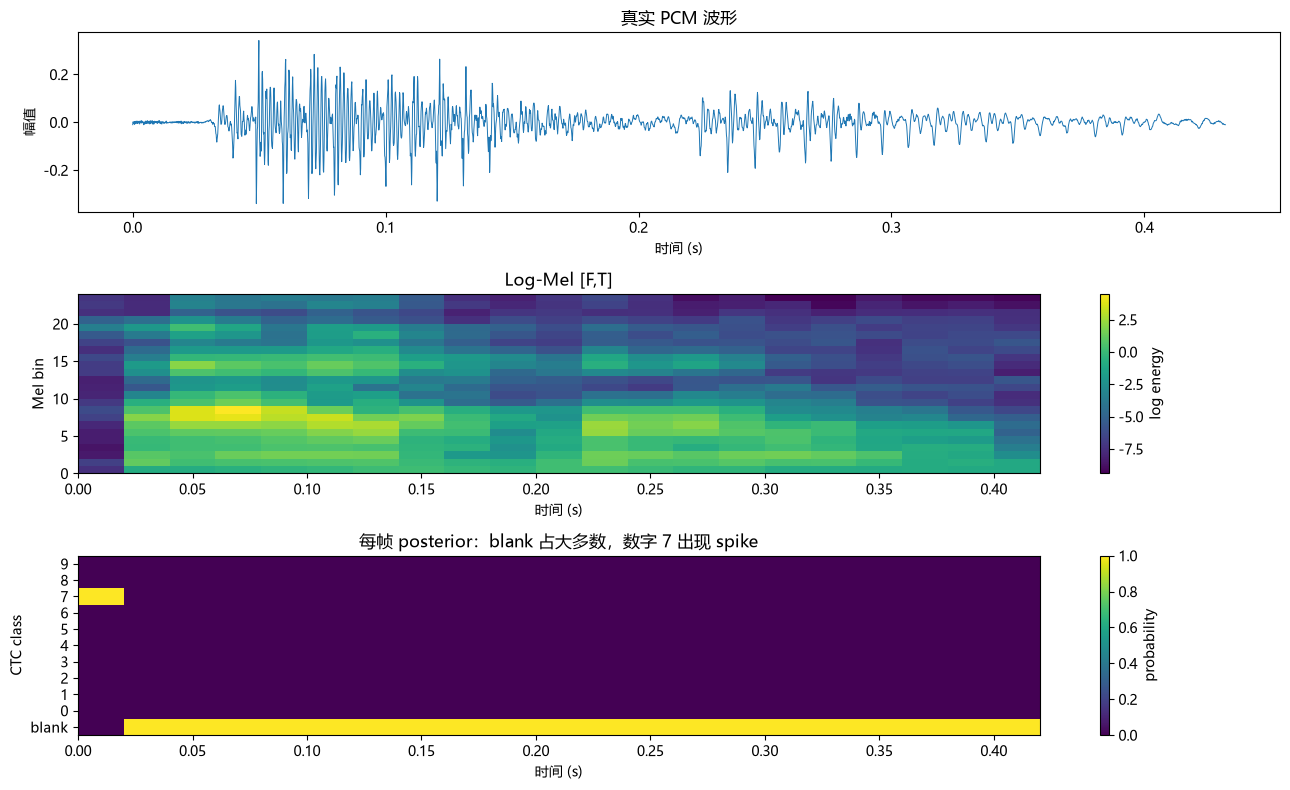

In [3]:
audio_path = ROOT / "data" / "spoken_digits_parts" / "7_jackson_0.wav"
waveform = load_mono_audio(audio_path, config.sample_rate)
frontend = LogMelFrontend(config)
features = frontend(waveform)
normalized = (features - engine.feature_mean) / engine.feature_std
lengths = torch.tensor([len(normalized)])
with torch.inference_mode():
    logits, output_lengths = engine.model(normalized.unsqueeze(0), lengths)
    probabilities = logits[0].softmax(dim=-1)
frame_ids = probabilities.argmax(dim=-1).tolist()
decoded, token_ids = ctc_collapse(frame_ids, engine.tokens)

print("waveform [samples]        =", tuple(waveform.shape))
print("Log-Mel [time, mel]      =", tuple(features.shape))
print("batch [batch,time,mel]   =", tuple(normalized.unsqueeze(0).shape))
print("logits [batch,time,class]=", tuple(logits.shape))
print("frame ids → CTC collapse =", frame_ids, "→", decoded)
display(Audio(waveform.numpy(), rate=config.sample_rate))

fig, ax = plt.subplots(3, 1, figsize=(13, 8))
t = np.arange(len(waveform)) / config.sample_rate
ax[0].plot(t, waveform.numpy(), lw=.7)
ax[0].set(xlabel="时间 (s)", ylabel="幅值", title="真实 PCM 波形")
image = ax[1].imshow(features.T.numpy(), origin="lower", aspect="auto",
                     extent=[0, len(features)*config.hop_length/config.sample_rate, 0, config.n_mels])
ax[1].set(xlabel="时间 (s)", ylabel="Mel bin", title="Log-Mel [F,T]")
plt.colorbar(image, ax=ax[1], label="log energy")
prob_image = ax[2].imshow(probabilities.T.numpy(), origin="lower", aspect="auto",
                          extent=[0, len(probabilities)*config.hop_length/config.sample_rate, 0, 11], vmin=0, vmax=1)
ax[2].set_yticks(np.arange(11)+.5, ["blank", *engine.tokens])
ax[2].set(xlabel="时间 (s)", ylabel="CTC class", title="每帧 posterior：blank 占大多数，数字 7 出现 spike")
plt.colorbar(prob_image, ax=ax[2], label="probability")
plt.tight_layout(); plt.show()
assert decoded == "7"

### 为什么不能直接对每帧 argmax 拼字符串？

CTC 规定：先合并相邻重复类别，再删除 blank。比如类别路径 `[8,8,0,8]` 对应两个 `7`，因为 blank 把重复字符隔开；`[8,8,8]` 只对应一个 `7`。

Greedy 取一条最大概率路径；prefix beam 会把映射到同一文本的多条路径概率相加。因此单条最佳路径不一定属于总概率最大的文本。

In [4]:
examples = {
    "连续重复": [8, 8, 8],
    "blank 分隔": [8, 8, 0, 8],
    "两个数字": [2, 2, 0, 3, 3],
}
for name, path in examples.items():
    print(name, path, "->", ctc_collapse(path, engine.tokens)[0])
assert ctc_collapse([8,8,8], engine.tokens)[0] == "7"
assert ctc_collapse([8,8,0,8], engine.tokens)[0] == "77"

连续重复 [8, 8, 8] -> 7
blank 分隔 [8, 8, 0, 8] -> 77
两个数字 [2, 2, 0, 3, 3] -> 12


## 3. 先证明“管线正确”，再问“模型是否泛化”

下面做两组完全不同的评测：

- **training-style**：训练使用过的同一批 Jackson 单数字录音，主要验证保存、加载、前端和推理闭环；
- **speaker-disjoint probe**：george、nicolas、theo、yweweler 的数字 0～2，训练没有见过这些人，检验最初步的说话人泛化。

第一组高分不能替代第二组。更严格的生产测试还需要独立录音、更多数字组合、设备、噪声和口音。

training-style exact=10/10, CER=0.00%
speaker-disjoint exact=1/12, CER=133.33%
0_george_0         target=0 prediction=83
0_nicolas_0        target=0 prediction=<empty>
0_theo_0           target=0 prediction=9
0_yweweler_0       target=0 prediction=0
1_george_0         target=1 prediction=<empty>
1_nicolas_0        target=1 prediction=<empty>
1_theo_0           target=1 prediction=1407
1_yweweler_0       target=1 prediction=40
2_george_0         target=2 prediction=23
2_nicolas_0        target=2 prediction=9
2_theo_0           target=2 prediction=<empty>
2_yweweler_0       target=2 prediction=09


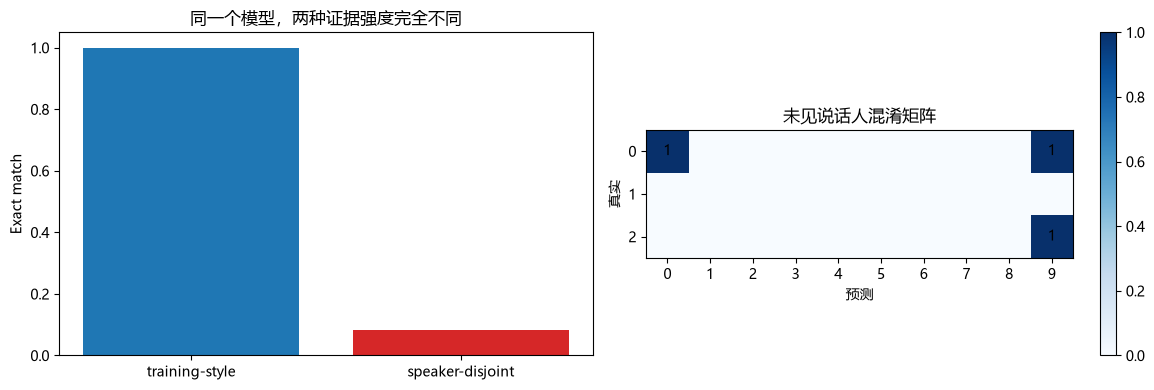

In [5]:
def cer_counts(reference, hypothesis):
    dp = np.zeros((len(reference)+1, len(hypothesis)+1), dtype=int)
    dp[:,0] = np.arange(len(reference)+1); dp[0,:] = np.arange(len(hypothesis)+1)
    for i in range(1, len(reference)+1):
        for j in range(1, len(hypothesis)+1):
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1,
                          dp[i-1,j-1] + (reference[i-1] != hypothesis[j-1]))
    return int(dp[-1,-1]), len(reference)

train_rows = []
for path in sorted((ROOT / "data" / "spoken_digits_parts").glob("*.wav")):
    reference = path.stem.split("_")[0]
    prediction = engine.recognize_file(path, chunk_samples=800).text
    train_rows.append((reference, prediction, path.stem))

unseen_rows = []
for path in sorted((ROOT / "data" / "fsdd_multispeaker").glob("*.wav")):
    reference = path.stem.split("_")[0]
    prediction = engine.recognize_file(path, chunk_samples=800).text
    unseen_rows.append((reference, prediction, path.stem))

def summarize(rows):
    exact = sum(ref == hyp for ref, hyp, _ in rows)
    errors, chars = map(sum, zip(*(cer_counts(ref, hyp) for ref, hyp, _ in rows)))
    return exact, len(rows), errors/chars

train_summary = summarize(train_rows)
unseen_summary = summarize(unseen_rows)
print(f"training-style exact={train_summary[0]}/{train_summary[1]}, CER={train_summary[2]:.2%}")
print(f"speaker-disjoint exact={unseen_summary[0]}/{unseen_summary[1]}, CER={unseen_summary[2]:.2%}")
for ref, hyp, name in unseen_rows:
    print(f"{name:18s} target={ref} prediction={hyp or '<empty>'}")

labels = list("0123456789")
confusion = np.zeros((10, 10), dtype=int)
insert_or_empty = 0
for ref, hyp, _ in unseen_rows:
    if len(hyp) == 1 and hyp in labels:
        confusion[int(ref), int(hyp)] += 1
    else:
        insert_or_empty += 1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["training-style", "speaker-disjoint"],
          [train_summary[0]/train_summary[1], unseen_summary[0]/unseen_summary[1]],
          color=["C0", "C3"])
ax[0].set(ylim=(0,1.05), ylabel="Exact match", title="同一个模型，两种证据强度完全不同")
image = ax[1].imshow(confusion[:3], cmap="Blues")
ax[1].set_xticks(range(10), labels); ax[1].set_yticks(range(3), list("012"))
ax[1].set(xlabel="预测", ylabel="真实", title="未见说话人混淆矩阵")
for i in range(3):
    for j in range(10):
        if confusion[i,j]: ax[1].text(j, i, str(confusion[i,j]), ha="center", va="center")
plt.colorbar(image, ax=ax[1]); plt.tight_layout(); plt.show()

assert train_summary[:2] == (10, 10)
assert train_summary[2] == 0
assert unseen_summary[0] < unseen_summary[1]

### 这是失败，还是成功？

两者都是：

- **工程闭环成功**：模型能训练、保存、加载、流式推理，训练风格样本全部识别；
- **泛化实验失败**：当前 checkpoint 的跨说话人 exact match 很低，远不能部署。

正确下一步不是隐藏低分，而是增加 speaker-disjoint 数据，定义 train/dev/test，做噪声/速度/增益增强，选择模型容量，监控 dev CER，并且只在最后一次使用 test。完整 FSDD 应固定到一个版本，例如上游 commit `26eb9aaf76e81b692f806f9140c2d2777410d7a1`，避免数据随时间漂移。

## 4. 流式正确性的三道独立证明

流式系统至少有三类状态，不能混成一个“cache”：

1. **波形/特征状态**：不足一窗的 samples 和 STFT overlap；
2. **声学模型状态**：当前模型是每层因果卷积的左上下文 cache；若换成 GRU，则是 recurrent hidden；
3. **CTC 解码状态**：上一 frame class，或 prefix beam 的 blank/nonblank 概率。

我们依次证明随机 waveform chunks 的特征相同、随机 feature chunks 的 logits 相同、多个 chunk size 的最终文字相同。

In [6]:
sequence_text = "1234"
sequence_waveform = join_digits(sequence_text, parts, sample_rate)
offline_features = LogMelFrontend(config)(sequence_waveform)

def random_boundaries(length, seed):
    rng = np.random.default_rng(seed)
    boundaries, cursor = [], 0
    while cursor < length:
        cursor = min(length, cursor + int(rng.integers(1, 1201)))
        boundaries.append(cursor)
    return boundaries

feature_errors = []
for seed in range(50):
    streaming_frontend = StreamingLogMelFrontend(config)
    output = []; start = 0
    boundaries = random_boundaries(len(sequence_waveform), seed)
    for end in boundaries:
        output.append(streaming_frontend.accept(sequence_waveform[start:end], final=end == len(sequence_waveform)))
        start = end
    streamed_features = torch.cat(output)
    feature_errors.append(float((streamed_features - offline_features).abs().max()))

normalized_sequence = (offline_features - engine.feature_mean) / engine.feature_std
with torch.inference_mode():
    whole_logits, _ = engine.model(normalized_sequence.unsqueeze(0), torch.tensor([len(normalized_sequence)]))
    state = None; logit_pieces = []
    for start, end in [(0,3), (3,11), (11,12), (12,len(normalized_sequence))]:
        piece, state = engine.model.forward_chunk(normalized_sequence[None,start:end], state)
        logit_pieces.append(piece)
    chunk_logits = torch.cat(logit_pieces, dim=1)
logit_error = float((whole_logits - chunk_logits).abs().max())

chunk_sizes = [1, 137, 400, 800, 1600, len(sequence_waveform)]
chunk_texts = {size: engine.recognize_waveform(sequence_waveform, chunk_samples=size).text for size in chunk_sizes}
print(f"50 组 waveform chunks: feature max error={max(feature_errors):.3e}")
print(f"whole vs feature chunks: logits max error={logit_error:.3e}")
print("不同 audio chunk 最终文本:", chunk_texts)

assert max(feature_errors) < 1e-5
assert logit_error < 1e-5
assert set(chunk_texts.values()) == {sequence_text}

50 组 waveform chunks: feature max error=9.537e-07
whole vs feature chunks: logits max error=2.861e-06
不同 audio chunk 最终文本: {1: '1234', 137: '1234', 400: '1234', 800: '1234', 1600: '1234', 17162: '1234'}


### 为什么“最终文字一样”仍不够？

不同 logits 可能碰巧 collapse 成同一文字。反过来，浮点微差也可能在决策边界改变文本。因此需要分层测试：数值等价、decoder state、最终文本、partial 行为和时间戳都要测。

特别测试 1-sample chunk 很慢，但善于暴露边界重置、漏 sample 和 off-by-one；生产 benchmark 则应使用真实网络 chunk 分布。

## 5. Partial、PGS 与“稳定”

实时系统会多次发送 partial。这里定义两个可计算量：

- `final-prefix agreement = LCP(partial, final) / len(partial)`：已经显示的字符中有多少最终保留；
- `revised`：新 partial 是否不再以旧 partial 开头。

PGS 在不同团队中可能有不同具体定义，使用前必须写清公式。不要只报 final CER：频繁回改即使最终正确，也会让字幕很难读。

In [7]:
def longest_common_prefix(a, b):
    count = 0
    for left, right in zip(a, b):
        if left != right: break
        count += 1
    return count

def stream_trace(chunk_samples=400, decoder="prefix_beam"):
    session = engine.start_session(decoder=decoder, beam_size=10)
    trace = []
    for start in range(0, len(sequence_waveform), chunk_samples):
        end = min(start+chunk_samples, len(sequence_waveform))
        update = session.accept_audio(sequence_waveform[start:end], final=end == len(sequence_waveform))
        trace.append({"time":end/sample_rate, "text":update.text, "revised":update.revised})
    final = trace[-1]["text"]
    for row in trace:
        row["agreement"] = (longest_common_prefix(row["text"], final) / len(row["text"])) if row["text"] else 1.0
    return trace

def show_stream(chunk_ms=50, decoder="prefix_beam"):
    chunk_samples = max(1, round(chunk_ms * sample_rate / 1000))
    trace = stream_trace(chunk_samples, decoder)
    changed = [row for i,row in enumerate(trace) if i == 0 or row["text"] != trace[i-1]["text"]]
    for row in changed:
        print(f"{row['time']:5.2f}s  partial={row['text'] or '<empty>':6s} revised={row['revised']}")
    plt.figure(figsize=(10, 3))
    plt.step([r["time"] for r in trace], [len(r["text"]) for r in trace], where="post", label="partial length")
    plt.ylim(-.1, len(sequence_text)+.5); plt.xlabel("已接收音频 (s)"); plt.ylabel("字符数")
    plt.title(f"{decoder}; chunk={chunk_ms} ms; final={trace[-1]['text']}; revisions={sum(r['revised'] for r in trace)}")
    plt.grid(alpha=.2); plt.tight_layout(); plt.show()

partial_ui = widgets.interactive(
    show_stream,
    chunk_ms=widgets.IntSlider(min=10, max=250, step=10, value=50, description="chunk ms", continuous_update=False),
    decoder=widgets.Dropdown(options=["greedy", "prefix_beam"], value="prefix_beam", description="decoder")
)
display(partial_ui)

clean_trace = stream_trace(400, "prefix_beam")
assert clean_trace[-1]["text"] == sequence_text
assert sum(row["revised"] for row in clean_trace) == 0

interactive(children=(IntSlider(value=50, continuous_update=False, description='chunk ms', max=250, min=10, st…

本条干净教学音频的 partial 没有回改，这只是一个样本的结果，不代表 PGS 已通过。真实验收必须覆盖低 SNR、相似词、热词/LM 开关、不同语速和长句，并报告 revision rate、稳定延迟和 final quality。

## 6. RTF、计算延迟、算法延迟和端点延迟

`RTF = 处理墙钟时间 / 音频时长`。RTF < 1 说明平均计算能跟上实时，但用户延迟还包括：

- chunk accumulation：攒够一块才开始算；
- feature window / encoder right context；
- decoder/stability 策略；
- endpoint 等尾部静音；
- 排队、网络、序列化和尾延迟。

平均 RTF 不能代替 P95/P99 latency，也不能跨机器直接比较。

In [8]:
torch.set_num_threads(1)
benchmark_waveform = join_digits("0123456789", parts, sample_rate)
audio_seconds = len(benchmark_waveform) / sample_rate
# warmup
for _ in range(3): engine.recognize_waveform(benchmark_waveform, chunk_samples=800)
latencies = []
for _ in range(30):
    start = time.perf_counter()
    engine.recognize_waveform(benchmark_waveform, chunk_samples=800)
    latencies.append(time.perf_counter() - start)
rtf_values = np.asarray(latencies) / audio_seconds
print(f"音频时长: {audio_seconds:.3f} s")
print(f"CPU latency P50/P95: {np.percentile(latencies,50)*1000:.2f}/{np.percentile(latencies,95)*1000:.2f} ms")
print(f"RTF mean/P95: {rtf_values.mean():.4f}/{np.percentile(rtf_values,95):.4f}")
print("注意：这是当前机器、单会话、热缓存、小模型结果，不是服务 SLA。")
assert np.isfinite(rtf_values).all()
assert rtf_values.mean() < 1

音频时长: 5.783 s
CPU latency P50/P95: 17.78/21.39 ms
RTF mean/P95: 0.0032/0.0037
注意：这是当前机器、单会话、热缓存、小模型结果，不是服务 SLA。


## 7. 解码、LM 与热词：只能重排仍存在的声学可能性

Prefix beam 保存多条 prefix，并可做 shallow fusion：

`score = CTC acoustic + alpha × LM + token bonus + hotword bonus`

LM 权重太小可能无效，太大会选择常见但没说过的串。热词也只能提高候选分数，不能被当作事实。下面用可控一帧 logits 证明 LM 能改变歧义选择；真实上线必须在 dev set 调权重，并在 test set 报告总体与热词分桶 CER。

In [9]:
ambiguous_logits = torch.tensor([[math.log(.01), math.log(.51), math.log(.48)]])
tokens_01 = ("0", "1")
acoustic_best = prefix_beam_search(ambiguous_logits, tokens_01, beam_size=3)[0]
lm = AddKBigramLanguageModel.fit(["0"] + ["1"]*10, tokens_01)
scorer = ShallowFusionScorer(language_model=lm, lm_weight=1.0)
fused_best = prefix_beam_search(ambiguous_logits, tokens_01, beam_size=3, extension_scorer=scorer)[0]
print("acoustic only:", acoustic_best.text, acoustic_best.score)
print("with domain LM:", fused_best.text, fused_best.score)
assert acoustic_best.text == "0"
assert fused_best.text == "1"

acoustic only: 0 -0.6733444929122925
with domain LM: 1 -0.8373474468229146


## 8. 故障注入与会话隔离

只测 happy path 很危险。至少主动制造：错误 feature dim、final 后继续发送、两个会话交错、空音频、错误 checkpoint version、采样率变化和 NaN。

下面验证两个并发会话的 feature buffer、模型 cache 和 decoder prefix 互不共享，并验证非法生命周期会明确失败。

In [10]:
wave_a = join_digits("12", parts, sample_rate)
wave_b = join_digits("78", parts, sample_rate)
session_a = engine.start_session()
session_b = engine.start_session()
final_a = final_b = None
max_len = max(len(wave_a), len(wave_b))
for start in range(0, max_len, 400):
    if start < len(wave_a):
        end_a = min(start+400, len(wave_a))
        final_a = session_a.accept_audio(wave_a[start:end_a], final=end_a == len(wave_a))
    if start < len(wave_b):
        end_b = min(start+400, len(wave_b))
        final_b = session_b.accept_audio(wave_b[start:end_b], final=end_b == len(wave_b))
print("interleaved sessions:", final_a.text, final_b.text)
assert final_a.text == "12" and final_b.text == "78"

try:
    session_a.accept_audio(torch.zeros(10))
except RuntimeError as error:
    print("final 后写入被拒绝:", error)
else:
    raise AssertionError("closed session unexpectedly accepted audio")

try:
    engine.model.forward_chunk(torch.zeros(1, 5, config.n_mels+1))
except ValueError as error:
    print("错误 feature dim 被拒绝:", error)
else:
    raise AssertionError("wrong feature dimension was not rejected")

interleaved sessions: 12 78
final 后写入被拒绝: streaming recognition session is already finalized
错误 feature dim 被拒绝: expected feature_dim=24, got 25


## 9. 训练复现：默认不重复训练，先读懂证据边界

训练命令：

```powershell
uv run python -m acoustic_engine.train_streaming_digits --epochs 300
```

它用真实 Jackson 数字片段合成 22 条短语音，计算统一 feature mean/std，用因果卷积编码器和 CTCLoss 过拟合这个小集合，再保存完整 engine contract。这个实验用于学习闭环，不是独立泛化实验。

训练一个真正可评估的版本，应下载固定 revision 的完整 FSDD，按 speaker-disjoint 划分 train/dev/test；只在 train 做增强，只在 dev 选择 epoch/LM 权重/阈值，最后一次在 test 报告 CER 和置信区间。禁止把 test speaker 的录音用于 CMVN、早停或调参。

In [11]:
RUN_TRAINING = False  # 改为 True 会重新训练，并覆盖默认 checkpoint；建议先改 --output 到新文件。
if RUN_TRAINING:
    raise RuntimeError("请先把训练命令的 --output 指向新文件，避免覆盖已验收 checkpoint")
else:
    print("本次使用已保存 checkpoint。你已通过推理、泛化、流式等价和性能四类独立检查。")

本次使用已保存 checkpoint。你已通过推理、泛化、流式等价和性能四类独立检查。


## 10. 自动化回归测试

单元测试覆盖：Log-Mel shape、训练/推理幅值契约、流式前端等价、CTC collapse、prefix beam 与穷举一致、LM/热词、变长 batch、checkpoint round trip、GRU/因果卷积 cache、流式 greedy/prefix state。

测试通过只证明被覆盖的契约，不证明跨说话人准确率。测试名本身应能告诉你“它提供了什么证据”。

基础不牢时可在终端启动小步交互教练：

```powershell
uv run python -m acoustic_engine.tutor
uv run python -m acoustic_engine.tutor --status
```

它一次只问一题，错误时逐级给提示，并把进度写入本地 `learning_progress.json`；通过知识题以后，仍需完成本 Notebook 的编码、泛化与故障注入任务。

In [12]:
test_process = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", str(ROOT/"tests"), "-p", "test_acoustic_engine.py"],
    cwd=ROOT, capture_output=True, text=True, check=False
)
print(test_process.stdout)
print(test_process.stderr)
assert test_process.returncode == 0


<REPO_ROOT>\.venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa
.............................
----------------------------------------------------------------------
Ran 29 tests in 0.758s

OK



## 11. 从教学引擎到生产 ASR：缺口清单

| 当前项目已有 | 真正产品仍缺 |
|---|---|
| 开源真实短音频 | 大规模、目标语言/设备/口音、合法数据治理 |
| Log-Mel + causal convolution | Conformer/RNN-T/CTC 选型、长上下文与规模训练 |
| Greedy/prefix + 小 bigram | 生产 beam/WFST/Neural LM、词表、热词治理 |
| 单会话 CPU benchmark | 并发、P99、内存、功耗、背压、过载保护 |
| chunk 数值等价 | 网络抖动、丢包、重连、endpoint、时间戳、PGS SLA |
| CER 小探针 | 大型盲测、分桶、显著性、回归门禁和线上监控 |
| PyTorch checkpoint | ONNX/INT8、目标硬件、服务契约、安全和回滚 |
| 数字文本 | 标点、ITN、说话人、语义、安全行动证据链 |

这不是否定小项目，而是学会给证据定边界。工程成熟度来自“每一层都知道尚未证明什么”。

## 12. 64 分综合答辩（16 题，每题 4 分）

1. 从 8 kHz WAV 到 logits，逐层写出 shape 和单位。
2. `n_fft=256, hop=160` 时，为什么 1 秒不是恰好 50 个 frame？写出 center=False 公式。
3. 为什么流式前端不能做整句 peak normalization？替代方案是什么？
4. 模型 cache、STFT buffer、CTC previous class 各保存什么，分别归谁所有？
5. 手算 `[8,8,0,8,0]` 的 CTC collapse；为什么两个 7 能保留？
6. Greedy 与 prefix beam 的核心差异是什么？为什么最佳 path 不等于最佳文本？
7. 训练风格高分、跨说话人低分同时出现说明什么？
8. 为完整 FSDD 设计 speaker-disjoint train/dev/test，并说明 CMVN、早停、LM 权重各用哪一份。
9. 为什么要同时测 feature/logit 数值等价和 final 文本等价？
10. 定义你的 PGS/稳定指标，并说明一个最终 CER 很低但体验很差的例子。
11. RTF=0.05 是否意味着用户 50 ms 得到 final？至少列出 4 个额外延迟源。
12. LM/热词怎样改变 prefix score？为什么权重过大会幻觉式纠错？
13. 两个 WebSocket 会话最少要隔离哪些状态？断开后怎样清理？
14. checkpoint 需要保存哪些字段？版本不匹配应静默兼容还是失败？
15. 为跨说话人 CER 从 75% 降到 10% 设计一次实验，写出变量、对照、指标和停止条件。
16. 给这个引擎写一张上线证据卡：质量、流式、性能、鲁棒、许可、安全、回滚各写一项。

<details><summary>评分要点</summary>

1. `[N] → [T,24] → [1,T,24] → [1,T,11] → ids/text`，时间单位由 sample rate/hop 给出。
2. `frames = 1 + floor((N-n_fft)/hop)`，无中心 padding。
3. 未来峰值未知；用训练一致的固定标尺、在线 AGC/CMVN 或已验证的流式归一化。
4. 声学历史、窗重叠 samples、跨 chunk 重复/blank；全部按 session 隔离。
5. `77`；blank 使两个相同 token 属于不同 run。
6. Greedy 取单条帧路径；prefix 汇总同一前缀多路径概率并保留 beam。
7. 管线能过拟合并运行，但说话人泛化证据失败，不能部署。
8. speaker 集合互斥；train 算增强/统计，dev 早停调参，test 只作最终报告。
9. 同文本可能掩盖数值错误，微小数值差又未必影响当前文本；分层定位更强。
10. 需给明确公式，如 revision rate、final-prefix agreement、stable delay；反复回改字幕即为例。
11. 不能；chunk、window/context、排队/网络、decoder stability、endpoint、序列化等。
12. extension 时加 LM/hotword log score；先验过强会压过声学证据。
13. feature buffer、模型 cache、decoder beam、累计时间、VAD/endpoint；断开要 finalize/释放并设 TTL。
14. format、frontend、model config/state、tokens/blank、CMVN、版本/哈希；不兼容应明确失败。
15. 应包含 speaker-disjoint 固定划分、数据/增强或模型单变量对照、dev CER/分桶、资源与显著性、不过拟合停止条件。
16. 每一类都要有可复现实验和阈值，而不是“已测试”一句话。

</details>

## 13. 结课口述：从代码作者升级为系统负责人

不看 Notebook，用 8 分钟讲清楚：

> “这条真人 WAV 怎样变成 streaming CTC 文本；三个状态如何跨 chunk；我用什么证据证明实现正确、实时且会话隔离；为什么 10/10 不是泛化准确率；下一轮怎样用 speaker-disjoint 全量数据训练，并如何把 WFST/LM、PGS、量化、语义和部署接回来。”

如果能给出每一步的输入、shape、状态、失败方式、指标和证据边界，你已经从“会运行 Notebook”进入了“能审查 ASR 系统”的阶段。下一轮应亲自完成全量数据实验报告，而不是继续只看答案。